In [3]:
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [4]:
import torch
import numpy as np
import pandas as pd
import cv2
import shapely

print("All packages loaded successfully")
print("Torch version:", torch.__version__)

All packages loaded successfully
Torch version: 2.8.0


In [14]:
import sys
!{sys.executable} model/OOD_supervised_contrastive_classifier.py

Loading OOD data...

Split sizes:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Train label distribution:
damage_label
no-damage       120576
major-damage     17327
minor-damage     17063
destroyed        11578
Name: count, dtype: int64

Test label distribution:
damage_label
no-damage       37859
destroyed        6089
major-damage     2260
minor-damage      625
Name: count, dtype: int64

Hold label distribution:
damage_label
no-damage       38388
minor-damage     8428
destroyed        3558
major-damage     3029
Name: count, dtype: int64

Image overlap check:
OOD_train intersection OOD_test: 0
OOD_train intersection OOD_hold: 0
OOD_test intersection OOD_hold: 0

Location overlap check:
OOD_train intersection OOD_test: 0
OOD_train intersection OOD_hold: 0
OOD_test intersection OOD_hold: 0

PASS: no image or location overlap.

Using device: mps

Starting ResNet50 supervised contrastive pretraining...
Contrastive Epoch 1/5: 100%|███| 5205/5205

# Model Performance Analysis and Interpretation

## 1. Training Dynamics

The training process shows stable behavior and no clear evidence of severe overfitting.

During the supervised contrastive pretraining stage, the contrastive loss decreases steadily from 3.9255 to 3.7599. This suggests that the encoder is learning a more structured representation space.

During the classifier training stage, training loss decreases from 0.5962 to 0.5353, while OOD test performance remains strong:

* Test Macro F1 ranges between 0.4298 and 0.4551
* Best performance is reached at epoch 5 with a Macro F1 of 0.4551

This suggests that:

* the contrastive encoder learns useful representations
* classifier training remains stable
* removing class weights improves calibration
* label smoothing helps reduce overly confident predictions

---

## 2. Overall Performance

The final performance of the model is:

| Split | Macro F1 |
| ----- | -------- |
| Test  | 0.4551   |
| Hold  | 0.4014   |

Key observations:

* performance improves substantially compared to the previous contrastive version
* the holdout score remains strong, although lower than the test score
* the model generalizes better than the baseline under OOD conditions
* the drop from test to hold indicates that unseen disaster locations still introduce meaningful distribution shift

---

## 3. Class-wise Performance

The model shows strong variation across classes.

### No damage

* Test F1: 0.8109  
* Hold F1: 0.8111  

Performance is high and highly stable across splits.

This indicates that the model learns robust features for identifying undamaged buildings across unseen locations.

---

### Minor damage

* Test F1: 0.0453  
* Hold F1: 0.3064  

Performance is very low on the test split but substantially higher on the holdout split.

This difference is strongly influenced by class distribution:

* minor damage is heavily underrepresented in the test split
* minor damage is much more represented in the hold split
* subtle damage remains difficult to identify reliably

---

### Major damage

* Test F1: 0.1756  
* Hold F1: 0.1857  

Performance is low but consistent across splits.

This suggests that major damage remains one of the most difficult classes, likely because it overlaps visually with both minor damage and destroyed buildings.

---

### Destroyed

* Test F1: 0.7889  
* Hold F1: 0.3023  

Performance is very strong on the test split but drops considerably on the hold split.

This suggests that the model learns strong features for destroyed buildings in some disaster contexts, but these features do not fully transfer across all unseen locations.

---

## 4. Precision Recall Trade-off

Compared to the previous contrastive model with class weights, the new model shows a better precision recall balance.

The model still over-predicts some damage classes, especially minor and major damage, but the over-prediction is less extreme than before.

For example, on the test split:

* minor-damage true count: 625
* minor-damage predicted count: 3043
* major-damage true count: 2260
* major-damage predicted count: 9121

This indicates that:

* the model remains sensitive to damage
* false positives are still present
* removing class weights reduced excessive minority-class prediction
* label smoothing improved prediction calibration

---

## 5. Effect of Removing Class Weights

In this version, class weights were removed and label smoothing was added.

This change was important because the previous contrastive model combined two mechanisms that both emphasized minority classes:

* supervised contrastive learning
* class-weighted cross entropy

This created an overcorrection, causing the model to predict damage classes too aggressively.

After removing class weights:

### Positive effects

* Test Macro F1 improved from 0.3686 to 0.4551
* Hold Macro F1 improved from 0.3662 to 0.4014
* prediction distributions became less extreme
* no-damage performance became much stronger and more stable
* overall calibration improved

### Remaining limitations

* minor and major damage still have low precision
* damage severity levels remain difficult to separate
* the model still shows some tendency to over-predict damage

---

## 6. Generalization to Holdout Data

The model achieves:

* Test Macro F1: 0.4551
* Hold Macro F1: 0.4014

The holdout performance is lower than the test performance, but remains substantially improved compared to the previous contrastive run.

This suggests that:

* contrastive representation learning improves OOD generalization
* the learned representations transfer reasonably well to unseen disaster locations
* distribution shift remains present, especially for destroyed and subtle damage classes

The performance gap between test and hold indicates that the hold split contains visual or label-distribution patterns that remain more difficult for the model.

---

## 7. Limitations

The experiment highlights several limitations:

* minor damage remains difficult to classify
* major damage remains visually ambiguous
* destroyed buildings generalize unevenly across locations
* test and hold splits have different class distributions
* the model still over-predicts some damage categories
* representation learning improves robustness but does not fully solve OOD generalization

These limitations suggest that the remaining errors are driven by both:

* visual ambiguity between damage levels
* distribution differences across disaster locations

---

## Final Interpretation

The revised supervised contrastive model provides the strongest representation-learning result so far.

Removing class weights and adding label smoothing substantially improved performance and reduced excessive damage over-prediction.

Overall:

* Test Macro F1 increased to 0.4551
* Hold Macro F1 increased to 0.4014
* no-damage classification became highly stable
* minor and major damage remain the most challenging classes
* contrastive learning improves OOD robustness, but class-level robustness remains uneven

This supports the interpretation that supervised contrastive learning improves the learned representation space and provides better generalization to unseen disaster locations, especially when not combined with overly aggressive class weighting.

Using contrastive naming

Using files:
/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_targets.npy
/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_preds.npy


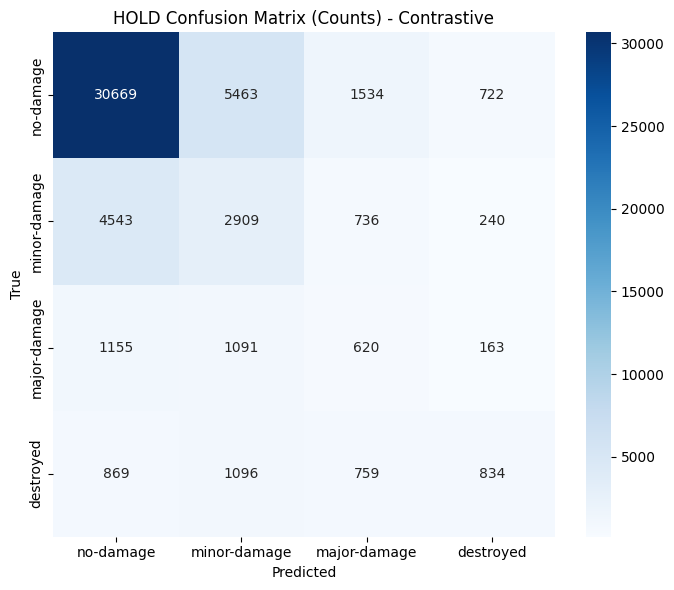

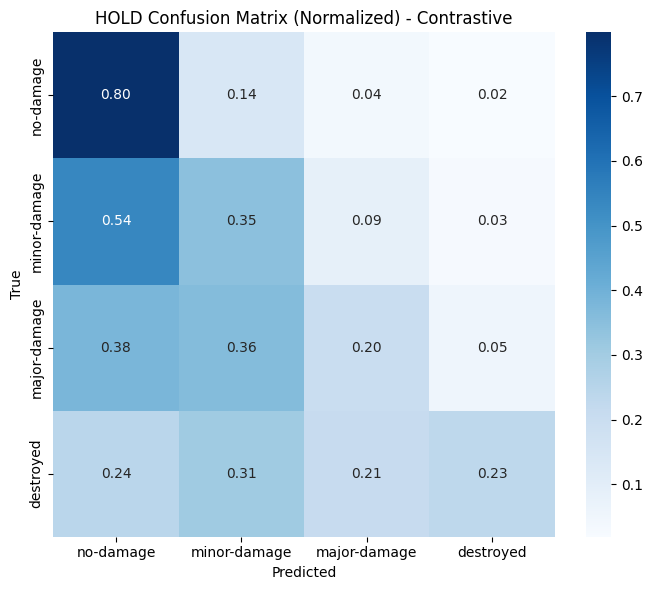

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

# =========================
# Configuration
# =========================

split = "hold"   # "test" or "hold"

labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]

PROJECT_ROOT = Path.cwd()

# output folder
candidate_paths = [
    PROJECT_ROOT / "OOD_training_outputs" / "resnet50_contrastive",
    Path.home() / "Desktop" / "OOD_training_outputs" / "resnet50_supervised_contrastive",
]

BASE_PATH = None
y_true_path = None
y_pred_path = None

# =========================
# Search logic (robust)
# =========================

for path in candidate_paths:

    # 🔴 Contrastive naming (most likely)
    contrastive_true = path / f"ood_{split}_targets.npy"
    contrastive_pred = path / f"ood_{split}_preds.npy"

    # fallback naming (just in case)
    alt_true = path / f"{split}_targets.npy"
    alt_pred = path / f"{split}_preds.npy"

    if contrastive_true.exists() and contrastive_pred.exists():
        BASE_PATH = path
        y_true_path = contrastive_true
        y_pred_path = contrastive_pred
        print("Using contrastive naming")
        break

    elif alt_true.exists() and alt_pred.exists():
        BASE_PATH = path
        y_true_path = alt_true
        y_pred_path = alt_pred
        print("Using alternative naming")
        break

# =========================
# Fail clearly if not found
# =========================

if BASE_PATH is None:
    print("Files not found. Available .npy files:\n")
    for path in candidate_paths:
        if path.exists():
            print(f"\n{path}:")
            for f in path.glob("*.npy"):
                print("  ", f.name)

    raise FileNotFoundError("Could not find matching prediction files.")

print(f"\nUsing files:\n{y_true_path}\n{y_pred_path}")

# =========================
# Load predictions
# =========================

y_true = np.load(y_true_path)
y_pred = np.load(y_pred_path)

# =========================
# Confusion matrices
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Counts) - Contrastive")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =========================
# Normalized version
# =========================

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"{split.upper()} Confusion Matrix (Normalized) - Contrastive")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

Available splits in CSV:
split
OOD_train    166544
OOD_hold      53403
OOD_test      46833
Name: count, dtype: int64

Rows in selected CSV split: 53403
Predictions: 53403
Targets: 53403

Available image IDs:
Series([], Name: count, dtype: int64)

Selected image_id: hurricane-michael_00000003
Number of buildings in selected image: 35


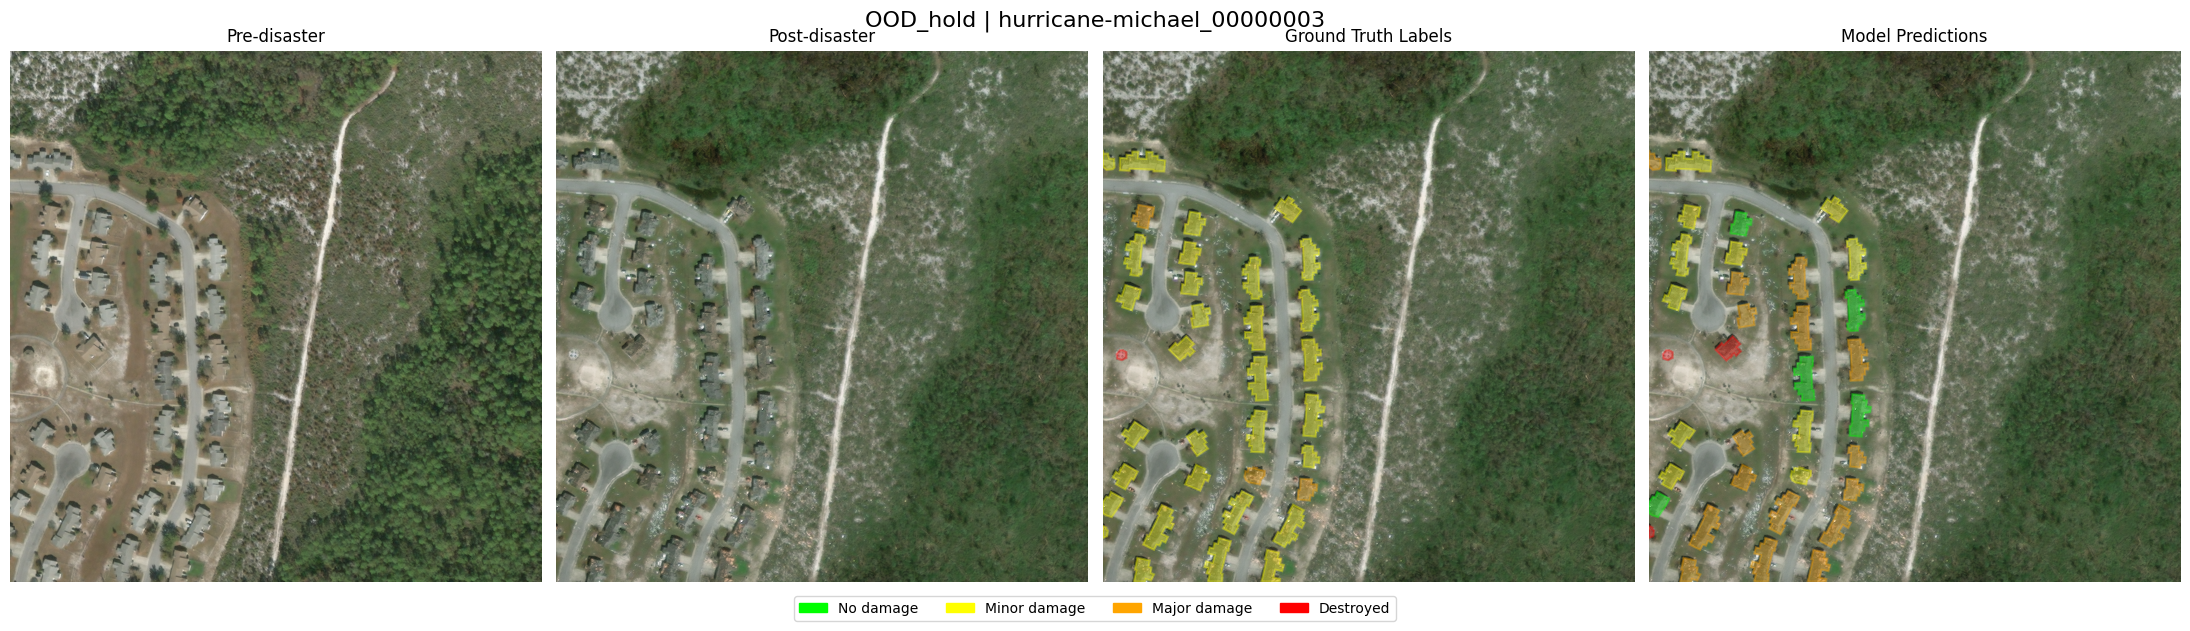

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt

# =========================
# Paths
# =========================
BASE_DIR = Path.home() / "Desktop"
CSV_PATH = BASE_DIR / "OOD_processed" / "buildings_all_OOD_with_crops.csv"
OUTPUT_DIR = BASE_DIR / "OOD_training_outputs" / "resnet50_supervised_contrastive"

# =========================
# Choose split
# =========================
# Your CSV uses: OOD_train, OOD_test, OOD_hold
CSV_SPLIT = "OOD_hold"

# Your prediction files use: ood_test_preds.npy, ood_hold_preds.npy
FILE_SPLIT = "hold"

# =========================
# Labels and colors
# =========================
LABELS = ["no-damage", "minor-damage", "major-damage", "destroyed"]

COLORS = {
    "no-damage": "lime",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
}

# =========================
# Load data
# =========================
df = pd.read_csv(CSV_PATH)

print("Available splits in CSV:")
print(df["split"].value_counts())

split_df = df[df["split"] == CSV_SPLIT].copy().reset_index(drop=True)

pred_path = OUTPUT_DIR / f"ood_{FILE_SPLIT}_preds.npy"
target_path = OUTPUT_DIR / f"ood_{FILE_SPLIT}_targets.npy"

if not pred_path.exists():
    raise FileNotFoundError(f"Missing prediction file: {pred_path}")

if not target_path.exists():
    raise FileNotFoundError(f"Missing target file: {target_path}")

preds = np.load(pred_path)
targets = np.load(target_path)

print("\nRows in selected CSV split:", len(split_df))
print("Predictions:", len(preds))
print("Targets:", len(targets))

if len(split_df) == 0:
    raise ValueError(
        f"No rows found for CSV_SPLIT='{CSV_SPLIT}'. "
        "Check the printed split names above and update CSV_SPLIT."
    )

if len(split_df) != len(preds):
    raise ValueError(
        f"Mismatch: selected CSV split has {len(split_df)} rows, "
        f"but predictions contain {len(preds)} values. "
        "CSV_SPLIT and FILE_SPLIT probably do not refer to the same split."
    )

if len(preds) != len(targets):
    raise ValueError(
        f"Mismatch: predictions contain {len(preds)} values, "
        f"but targets contain {len(targets)} values."
    )

# =========================
# Add predictions to dataframe
# =========================
split_df["pred_idx"] = preds
split_df["true_idx"] = targets
split_df["pred_label"] = split_df["pred_idx"].map(lambda i: LABELS[int(i)])
split_df["true_label"] = split_df["true_idx"].map(lambda i: LABELS[int(i)])

# =========================
# Select image
# =========================
counts = split_df["image_id"].value_counts()

print("\nAvailable image IDs:")
print(counts.head(0))

# Option A: automatically use the first available image
image_id = counts.index[520]


img_df = split_df[split_df["image_id"] == image_id].copy()

if img_df.empty:
    raise ValueError(f"No rows found for image_id='{image_id}'.")

print("\nSelected image_id:", image_id)
print("Number of buildings in selected image:", len(img_df))

# =========================
# Load images
# =========================
pre_path = Path(img_df.iloc[0]["pre_image_path"])
post_path = Path(img_df.iloc[0]["post_image_path"])

if not pre_path.exists():
    raise FileNotFoundError(f"Missing pre-disaster image: {pre_path}")

if not post_path.exists():
    raise FileNotFoundError(f"Missing post-disaster image: {post_path}")

pre = np.array(Image.open(pre_path))
post = np.array(Image.open(post_path))

# =========================
# Plotting helper
# =========================
def draw_polygons(ax, image, rows, label_col, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    for _, row in rows.iterrows():
        poly = wkt.loads(row["wkt"])
        label = row[label_col]
        color = COLORS[label]

        x, y = poly.exterior.xy
        coords = list(zip(x, y))

        patch = mpatches.Polygon(
            coords,
            closed=True,
            fill=True,
            alpha=0.35,
            edgecolor=color,
            facecolor=color,
            linewidth=1.5,
        )
        ax.add_patch(patch)

# =========================
# Legend
# =========================
legend_elements = [
    mpatches.Patch(color=COLORS["no-damage"], label="No damage"),
    mpatches.Patch(color=COLORS["minor-damage"], label="Minor damage"),
    mpatches.Patch(color=COLORS["major-damage"], label="Major damage"),
    mpatches.Patch(color=COLORS["destroyed"], label="Destroyed"),
]

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(pre)
axes[0].set_title("Pre-disaster")
axes[0].axis("off")

axes[1].imshow(post)
axes[1].set_title("Post-disaster")
axes[1].axis("off")

draw_polygons(
    axes[2],
    post,
    img_df,
    label_col="true_label",
    title="Ground Truth Labels",
)

draw_polygons(
    axes[3],
    post,
    img_df,
    label_col="pred_label",
    title="Model Predictions",
)

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.05),
)

plt.suptitle(f"{CSV_SPLIT} | {image_id}", fontsize=16)
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

OUTPUT_DIR = Path.home() / "Desktop" / "OOD_training_outputs" / "resnet50_supervised_contrastive"

print(OUTPUT_DIR.exists())
print(list(OUTPUT_DIR.glob("*")))

True
[PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/summary.json'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_targets.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_preds.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_latest.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_hold_confusion_matrix.npy'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/best_model.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_final.pt'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/contrastive_history.csv'), PosixPath('/Users/paolo/Desktop/OOD_training_outputs/resnet50_supervised_contrastive/ood_test_preds.npy'), PosixPath('/Users/p